In [52]:
import random
import numpy as np
import matplotlib.pyplot as plt

fitness_otimo = 0.0


In [53]:
# Função objetivo: f(x, y) = x^2 + y^2
def objective_function(D, solution):
    x, y = solution[0], solution[1]
    return x**2 + y**2


In [57]:
class BatAlgorithm():
    def __init__(self, D, NP, N_Gen, A, r, Qmin, Qmax, Lower, Upper, function, fitness_otimo):
        self.D = D  # Dimension
        self.NP = NP  # Population size
        self.N_Gen = N_Gen  # Generations
        self.A = A  # Loudness
        self.r = r  # Pulse rate
        self.Qmin = Qmin  # Frequency min
        self.Qmax = Qmax  # Frequency max
        self.Lower = Lower  # Lower bound
        self.Upper = Upper  # Upper bound
        self.f_min = 0.0  # Minimum fitness
        self.fitness_otimo = fitness_otimo  # Fitness ótimo fornecido
        
        self.Lb = [0] * self.D  # Lower bound
        self.Ub = [0] * self.D  # Upper bound
        self.Q = [0] * self.NP  # Frequency

        self.v = [[0 for i in range(self.D)] for j in range(self.NP)]  # Velocity
        self.Sol = [[0 for i in range(self.D)] for j in range(self.NP)]  # Population of solutions
        self.Fitness = [0] * self.NP  # Fitness
        self.best = [0] * self.D  # Best solution
        self.Fun = function  # Objective function
    
    def best_bat(self):
        i = 0
        j = 0
        for i in range(self.NP):
            if self.Fitness[i] < self.Fitness[j]:
                j = i
        for i in range(self.D):
            self.best[i] = self.Sol[j][i]
        self.f_min = self.Fitness[j]
        
        # Comparando com o fitness ótimo
        print(f"Melhor solução atual: {self.best}, com fitness: {self.f_min}")
        print(f"Fitness ótimo esperado: {self.fitness_otimo}")
        
        # Avaliar quão perto o algoritmo chegou do fitness ótimo
        print(f"Distância do fitness ótimo: {abs(self.f_min - self.fitness_otimo)}")
        
    def init_bat(self):
        print("\nInicializando morcegos...")

        for i in range(self.D):
            self.Lb[i] = self.Lower
            self.Ub[i] = self.Upper

        for i in range(self.NP):
            self.Q[i] = 0
            for j in range(self.D):
                rnd = np.random.uniform(0, 1)
                self.v[i][j] = 0.0
                self.Sol[i][j] = self.Lb[j] + (self.Ub[j] - self.Lb[j]) * rnd
            self.Fitness[i] = self.Fun(self.D, self.Sol[i])

        self.best_bat()
    
    def simplebounds(self, val, lower, upper):
        if val < lower:
            val = lower
        if val > upper:
            val = upper
        return val
    
    def move_bat(self):
        S = [[0.0 for i in range(self.D)] for j in range(self.NP)]

        self.init_bat()

        history = []  # List to store history of positions
        all_positions = []  # List to store all positions for trajectory plotting

        for t in range(self.N_Gen):
            print(f"\nGeração {t + 1}...")  # Iteração (geração)
            for i in range(self.NP):
                print(f"\n  Morcego {i + 1}:")
                
                rnd = np.random.uniform(0, 1)
                self.Q[i] = self.Qmin + (self.Qmax - self.Qmin) * rnd
                print(f"    Frequência Q[{i}] = {self.Q[i]}")

                for j in range(self.D):
                    self.v[i][j] = self.v[i][j] + (self.Sol[i][j] - self.best[j]) * self.Q[i]
                    S[i][j] = self.Sol[i][j] + self.v[i][j]

                    S[i][j] = self.simplebounds(S[i][j], self.Lb[j], self.Ub[j])

                print(f"    Nova posição após atualização: {S[i]}")

                rnd = np.random.random_sample()

                if rnd > self.r:
                    for j in range(self.D):
                        S[i][j] = self.best[j] + 0.001 * random.gauss(0, 1)
                        S[i][j] = self.simplebounds(S[i][j], self.Lb[j], self.Ub[j])

                    print(f"    Caminhada aleatória aplicada, nova posição: {S[i]}")

                Fnew = self.Fun(self.D, S[i])

                print(f"    Fitness da nova posição: {Fnew}")

                rnd = np.random.random_sample()

                if (Fnew <= self.Fitness[i]) and (rnd < self.A):
                    for j in range(self.D):
                        self.Sol[i][j] = S[i][j]
                    self.Fitness[i] = Fnew
                    print(f"    Posição aceita, fitness atualizado: {self.Fitness[i]}")

                if Fnew <= self.f_min:
                    for j in range(self.D):
                        self.best[j] = S[i][j]
                    self.f_min = Fnew
                    print(f"    Nova melhor solução encontrada: {self.best}, com fitness: {self.f_min}")

            # Salvar histórico de melhor fitness ao longo das gerações
            history.append(np.copy(self.best))  
            all_positions.append(np.copy(self.Sol))

            # Comparação a cada geração
            print(f"\nApós geração {t + 1}, distância do fitness ótimo: {abs(self.f_min - self.fitness_otimo)}")
        
        return self.f_min, history, all_positions


In [67]:
def objective_function(D, solution):
    # Função de exemplo (f(x) = x^2)
    return sum(x**2 for x in solution)

# Defina o fitness ótimo (fitness ótimo para f(x) = 0)
fitness_otimo = 0.0

# Inicializando o algoritmo Bat com o fitness ótimo conhecido
bat = BatAlgorithm(D=2, NP=10, N_Gen=50, A=0.5, r=0.5, Qmin=0, Qmax=2, Lower=-5, Upper=5, 
                   function=objective_function, fitness_otimo=fitness_otimo)

best_fitness, history, all_positions = bat.move_bat()



Inicializando morcegos...
Melhor solução atual: [1.0981890585944338, 0.993500933013264], com fitness: 2.193063312314755
Fitness ótimo esperado: 0.0
Distância do fitness ótimo: 2.193063312314755

Geração 1...

  Morcego 1:
    Frequência Q[0] = 1.1431687666967874
    Nova posição após atualização: [2.4007275026394, 5]
    Fitness da nova posição: 30.76349254192921

  Morcego 2:
    Frequência Q[1] = 1.4238740106870547
    Nova posição após atualização: [1.0981890585944338, 0.993500933013264]
    Fitness da nova posição: 2.193063312314755
    Posição aceita, fitness atualizado: 2.193063312314755
    Nova melhor solução encontrada: [1.0981890585944338, 0.993500933013264], com fitness: 2.193063312314755

  Morcego 3:
    Frequência Q[2] = 1.3742985992147685
    Nova posição após atualização: [4.109693797453839, -3.009820553724741]
    Fitness da nova posição: 25.948602874454465

  Morcego 4:
    Frequência Q[3] = 0.8666348273922349
    Nova posição após atualização: [-5, -5]
    Fitness d


Melhor valor de fitness encontrado: 0.001283706111787785


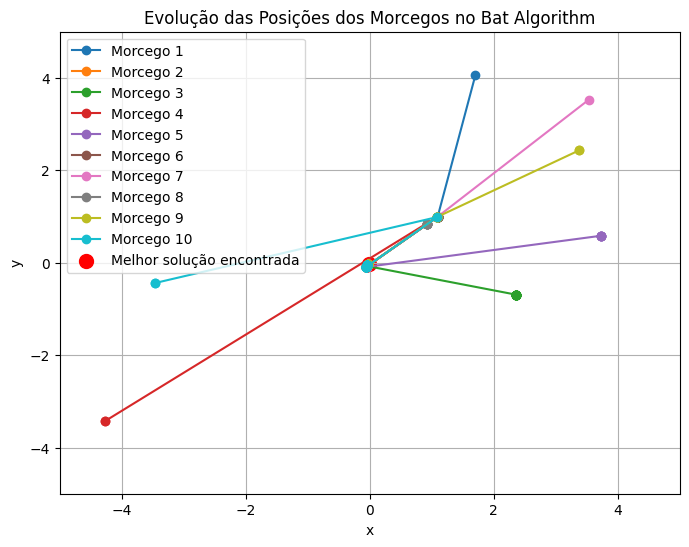

In [68]:
# Exibindo o melhor valor de fitness encontrado
print(f"\nMelhor valor de fitness encontrado: {best_fitness}")

# Plotando a trajetória dos morcegos
plt.figure(figsize=(8, 6))

# Plotando a trajetória de todos os morcegos
for i in range(10):
    all_positions_array = np.array(all_positions)  # Convertendo para array numpy
    # Garantindo que todos os morcegos tenham sua trajetória plotada, mesmo que não tenham se movido
    if np.any(np.array(all_positions_array[:, i, :]) != 0):  # Verifica se o morcego se moveu
        plt.plot(all_positions_array[:, i, 0], all_positions_array[:, i, 1], marker='o', linestyle='-', label=f'Morcego {i+1}')

# Plotando o melhor ponto (solução final)
plt.scatter(history[-1][0], history[-1][1], color='red', label="Melhor solução encontrada", s=100)

# Rótulos e títulos
plt.title("Evolução das Posições dos Morcegos no Bat Algorithm")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.legend()
plt.grid(True)
plt.show()